## CLASSIFICAÇÃO Pipeline e Grid Search CV

### PARAMETROS

In [290]:
# PARÂMETROS
random_seed = 42
k_of_k_folds = 5
k_features = [1, 2, 3, 4]

# ÁRVORE DE DECISÃO
min_leafs = [5, 6, 7, 8, 9, 10]

# SVC
kernels = ['rbf', 'sigmoid']
gammas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
Cs = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# ENSEMBLE
estimators = [2, 3, 4, 5]

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [291]:
from itertools import product

import numpy
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier,
                              RandomForestClassifier, StackingClassifier)
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, NuSVC
from sklearn.tree import DecisionTreeClassifier

In [292]:
class DummyClassifier(ClassifierMixin, BaseEstimator):
    def fit(self, X, y):
        self.classes_ = numpy.unique(y)
        return self

    def predict(self, X):
        return numpy.random.choice(self.classes_, size=X.shape[0])

### IMPORT IRIS

In [293]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

iris

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### PAIRPLOT

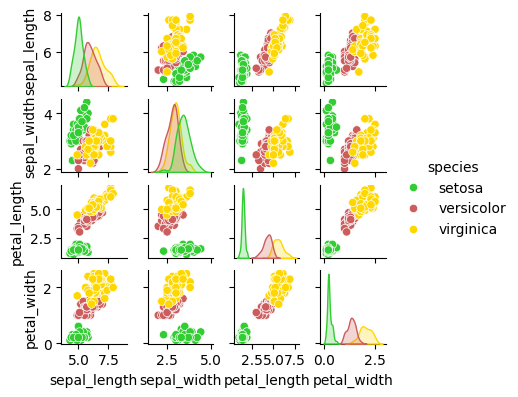

In [294]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.0)

### LOOP DE TREINAMENTO

> Pipelines

> GridSearchCV

In [295]:
# RANDOM SEED
numpy.random.seed(random_seed)

all_x_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

X = iris[all_x_cols]
y = iris["target"]

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("selection", SelectKBest()),
    ("extraction", PCA()),
    ("algorithm", DummyClassifier())
])

param_grid = [{
    "algorithm" : [DecisionTreeClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__min_samples_leaf": min_leafs
},
{
    "algorithm" : [SVC()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__kernel": kernels,
    "algorithm__gamma": gammas,
    "algorithm__C": Cs
},
{
    "algorithm": [RandomForestClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__min_samples_leaf": min_leafs,
    "algorithm__n_estimators": estimators
},
{
    "algorithm": [AdaBoostClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__n_estimators": estimators,
    "algorithm__estimator": [DecisionTreeClassifier()],
    "algorithm__estimator__min_samples_leaf": min_leafs
},
{
    "algorithm": [AdaBoostClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__n_estimators": estimators,
    "algorithm__estimator": [SVC()],
    "algorithm__estimator__kernel": kernels,
    "algorithm__estimator__gamma": gammas,
    "algorithm__estimator__C": Cs
},
{
    "algorithm": [BaggingClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__n_estimators": estimators,
    "algorithm__estimator": [DecisionTreeClassifier()],
    "algorithm__estimator__min_samples_leaf": min_leafs
},
{
    "algorithm": [BaggingClassifier()],
    "selection__k": k_features,
    "extraction" : [None, PCA()],
    "algorithm__n_estimators": estimators,
    "algorithm__estimator": [SVC()],
    "algorithm__estimator__kernel": kernels,
    "algorithm__estimator__gamma": gammas,
    "algorithm__estimator__C": Cs
}
]

search = GridSearchCV(model, param_grid, cv=k_of_k_folds, verbose=2, n_jobs=-1).fit(X, y)

Fitting 5 folds for each of 5808 candidates, totalling 29040 fits


In [296]:
search

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selection', SelectKBest()),
                                       ('extraction', PCA()),
                                       ('algorithm', DummyClassifier())]),
             n_jobs=-1,
             param_grid=[{'algorithm': [DecisionTreeClassifier()],
                          'algorithm__min_samples_leaf': [5, 6, 7, 8, 9, 10],
                          'extraction': [None, PCA()],
                          'selection__k': [1, 2, 3, 4]},
                         {'algorithm': [SVC()],
                          'algorithm__C':...
                          'selection__k': [1, 2, 3, 4]},
                         {'algorithm': [BaggingClassifier()],
                          'algorithm__estimator': [SVC()],
                          'algorithm__estimator__C': [0.001, 0.01, 0.1, 1.0,
                                                      10.0, 100.0],
                          'algorithm__estimator__gamma': [0.001, 0.01, 0.1, 1.0,
                                                          10.0, 100.0],
                          'algorithm__estimator__kernel': ['rbf', 'sigmoid'],
                          'algorithm__n_estimators': [2, 3, 4, 5],
                          'extraction': [None, PCA()],
                          'selection__k': [1, 2, 3, 4]}],
             verbose=2)

In [297]:
pandas.DataFrame(search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_algorithm__min_samples_leaf,param_extraction,param_selection__k,param_algorithm__C,param_algorithm__gamma,...,param_algorithm__estimator__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006468,0.000386,0.003072,0.000544,DecisionTreeClassifier(),5.0,None,1,NaN,NaN,...,NaN,"{'algorithm': DecisionTreeClassifier(), 'algor...",0.933333,1.000000,0.866667,0.933333,1.000000,0.946667,0.049889,1312
1,0.006898,0.000545,0.003338,0.000448,DecisionTreeClassifier(),5.0,None,2,NaN,NaN,...,NaN,"{'algorithm': DecisionTreeClassifier(), 'algor...",0.966667,1.000000,0.900000,0.866667,1.000000,0.946667,0.054160,1312
2,0.008727,0.002528,0.003684,0.001590,DecisionTreeClassifier(),5.0,None,3,NaN,NaN,...,NaN,"{'algorithm': DecisionTreeClassifier(), 'algor...",0.966667,1.000000,0.900000,0.866667,1.000000,0.946667,0.054160,1312
3,0.008822,0.002009,0.004121,0.001985,DecisionTreeClassifier(),5.0,None,4,NaN,NaN,...,NaN,"{'algorithm': DecisionTreeClassifier(), 'algor...",0.966667,1.000000,0.900000,0.866667,1.000000,0.946667,0.054160,1312
4,0.010662,0.003453,0.004605,0.002816,DecisionTreeClassifier(),5.0,PCA(),1,NaN,NaN,...,NaN,"{'algorithm': DecisionTreeClassifier(), 'algor...",0.933333,1.000000,0.866667,0.933333,1.000000,0.946667,0.049889,1312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5803,0.024075,0.003577,0.006300,0.001118,BaggingClassifier(),NaN,None,4,NaN,NaN,...,sigmoid,"{'algorithm': BaggingClassifier(), 'algorithm_...",0.666667,0.733333,0.666667,0.566667,0.666667,0.660000,0.053333,4041
5804,0.020039,0.000596,0.005456,0.001151,BaggingClassifier(),NaN,PCA(),1,NaN,NaN,...,sigmoid,"{'algorithm': BaggingClassifier(), 'algorithm_...",0.366667,0.600000,0.433333,0.666667,0.566667,0.526667,0.110353,4696
5805,0.023179,0.005015,0.008044,0.002034,BaggingClassifier(),NaN,PCA(),2,NaN,NaN,...,sigmoid,"{'algorithm': BaggingClassifier(), 'algorithm_...",0.666667,0.666667,0.666667,0.533333,0.333333,0.573333,0.130639,4544
5806,0.023776,0.006866,0.007727,0.003393,BaggingClassifier(),NaN,PCA(),3,NaN,NaN,...,sigmoid,"{'algorithm': BaggingClassifier(), 'algorithm_...",0.533333,0.566667,0.633333,0.533333,0.566667,0.566667,0.036515,4567


### PICK DO MELHOR MODELO

In [298]:
best_model = search.best_estimator_

### MATRIZ DE CONFUSÃO

In [299]:
winner_y_pred = best_model.predict(X)
ok_class = []
for ix in range(len(y)):
    ok_class.append(y[ix] == winner_y_pred[ix])

iris[[not ok for ok in ok_class]]

,sepal_length,sepal_width,petal_length,petal_width,target,species
70,5.9,3.2,4.8,1.8,1,versicolor
77,6.7,3.0,5.0,1.7,1,versicolor
83,6.0,2.7,5.1,1.6,1,versicolor


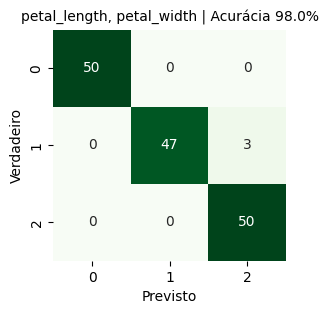

In [301]:
x_cols = iris[all_x_cols].columns[best_model['selection'].get_support()].to_list()

fig = pyplot.figure(figsize=(3, 3))
# PLOT CONFUSION MATRIX
conf_matrix = confusion_matrix(y, winner_y_pred)

ax = fig.add_subplot(111)
_ = seaborn.heatmap(conf_matrix, annot=True, cmap='Greens', cbar=False, ax=ax)
_ = ax.set_xlabel('Previsto')
_ = ax.set_ylabel('Verdadeiro')
# _ = ax.set_xticklabels(iris['flower'].unique(), rotation=45, ha='right')
# _ = ax.set_yticklabels(iris['flower'].unique(), rotation=0, ha='right')
# _ = ax.set_title(f'Vencedor: {winner.fk} | treino {100.0*winner_train_accuracy:.0f}% | teste {100.0*winner.hit:.0f}%')
best_feat_string = ', '.join(x_cols)
_ = ax.set_title(f'{best_feat_string} | Acurácia {100.0*search.best_score_:.1f}%', size=10)

In [ ]:
# if len(x_cols) == 2:
#     # CLASS COLOR GRID & CLASS EVALUATION
#     grid_n_points = 500
#     species = sorted(iris['target'].unique().tolist())

#     # X0 W JITTER
#     X_plot = iris[x_cols].to_numpy()
#     x0_grid = numpy.linspace(0, X_plot[:, 0].max(), grid_n_points)
#     x1_grid = numpy.linspace(0, X_plot[:, 1].max(), grid_n_points)
#     X_g = numpy.array(list(product(x0_grid, x1_grid)))
#     df_X_g = pandas.DataFrame(X_g, columns=x_cols)
#     # X_g_scaled = best_model_scaler.transform(df_X_g)
#     Y_g = best_model.predict(X_g)
#     Y_g_class = numpy.array([species[x] for x in Y_g])
#     Y_est = best_model.predict(X)
#     Y_class_est = numpy.array([species[x] for x in Y_est])

#     color_list = ['steelblue', 'green', 'orange']
#     background_color_list = ['skyblue', 'limegreen', 'moccasin']
#     marker_list = ['v', 'o', '^']

#     # GIVE COLOURS TO CLASS
#     color_dict = {}
#     bg_color_dict = {}
#     marker_dict = {}
#     ix_color = 0
#     for specie in species:
#         color_dict[specie] = color_list[ix_color]
#         marker_dict[specie] = marker_list[ix_color]
#         bg_color_dict[specie] = background_color_list[ix_color]
#         ix_color += 1

#     # CLASSIFICATION FIGURE
#     fig = pyplot.figure(figsize=(6, 6))
#     ax = fig.add_subplot(111)

#     # PLOT CLASS REGION
#     for specie in species:
#         ix_class_cloud = Y_g_class == specie
#         x_0_cloud = X_g[ix_class_cloud, 0]
#         x_1_cloud = X_g[ix_class_cloud, 1]
#         _ = ax.scatter(x_0_cloud, x_1_cloud, marker='o', color=bg_color_dict[specie], alpha=0.25)

#     # PLOT FLOWERS
#     for specie in species:
#         ix_class = iris['target'] == specie
#         x_0 = X_plot[ix_class, 0]
#         x_1 = X_plot[ix_class, 1]
#         _ = ax.scatter(x_0, x_1, color=color_dict[specie], marker=marker_dict[specie], alpha=0.85, s=100, label=specie)
#         _ = ax.legend(loc='upper left', fontsize=8, markerscale=0.75)

#     # PLOT MISCLASSFIED TAG
#     nok_vectors = X_plot[[not ok for ok in ok_class]]
#     _ = ax.scatter(nok_vectors[:, 0], nok_vectors[:, 1], color='red', marker='x', s=50, label='Misclassified')

#     # support_vectors = X_plot[best_model.support_]
#     # _ = ax.scatter(support_vectors[:, 0], support_vectors[:, 1], color='red', marker='x', s=50, label='Support Vectors')
#     _ = ax.set_xlim([0.0, X_g[:, 0].max()])
#     _ = ax.set_ylim([0.0, X_g[:, 1].max()])
#     _ = ax.set_title(f"{' & '.join(x_cols)} / validation {100.0*search.best_score_:.0f}%", size=10)

CONFUSÃO + ROC + SUPERFÍCIE DE SEPARAÇÃO MELHOR MODELO

LEARNING CURVE MELHOR K VS REGRESSÃO LOGÍSTICA

FLUTUAÇÃO DOS PARÂMETROS DA REGRESSÃO LOGÍSTICA